In [1]:
import sys
import os

import numpy as np
import random

import torch
import torch.nn as nn
from torchinfo import summary
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np 
from collections import Counter

BASE_FOLDER = os.path.dirname(os.getcwd())
sys.path.append(BASE_FOLDER)

from src.models import *
from src.utils import *

In [2]:
def init(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
init()

In [4]:
DATASET_FOLDER = os.path.join(BASE_FOLDER, "data", "recognition")
IMAGES_FOLDER = os.path.join(DATASET_FOLDER, "faces")
CHECKPOINTS_FOLDER = os.path.join(BASE_FOLDER, "checkpoints", "recognition_2")
MODEL_NAME = "custom"
EPOCHS = 200

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
images = os.listdir(IMAGES_FOLDER)

In [6]:
len(images)

2562

In [7]:
# labels = set()
# for filename in images:
#     class_name: str = filename.split("_")[0]
#     if class_name not in labels:
#         labels.add(class_name.lower())

# with open("labels.txt", "w", encoding="utf-8") as f:
#     for name in labels:
#         f.write(name + "\n")

In [8]:
with open(os.path.join(CHECKPOINTS_FOLDER, "labels.txt"), "r", encoding="utf-8") as f:
    labels = [line.strip() for line in f.readlines()]
len(labels)

31

In [9]:
ds = dict()

for filename in images:
    class_name = (filename.split("_")[0]).lower()
    if class_name not in ds:
        ds[class_name] = []
    ds[class_name].append(filename)

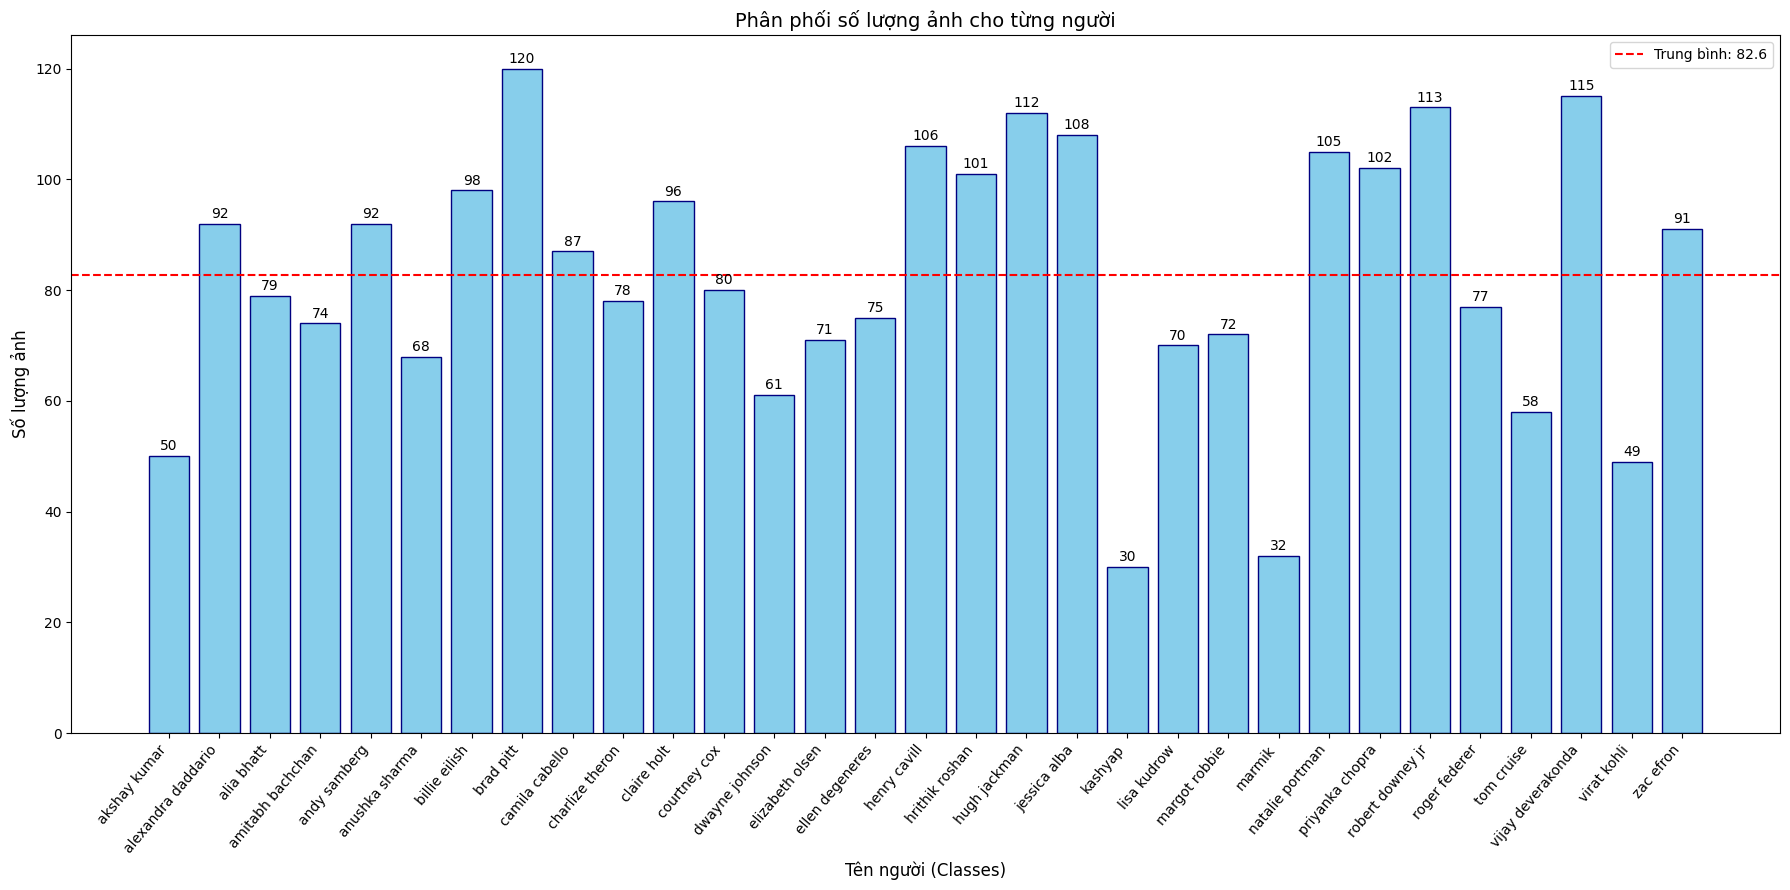

In [10]:
names = list(ds.keys())
counts = [len(files) for files in ds.values()]

plt.figure(figsize=(18, 9))
bars = plt.bar(names, counts, color="skyblue", edgecolor="navy")

plt.xlabel("Tên người (Classes)", fontsize=12)
plt.ylabel("Số lượng ảnh", fontsize=12)
plt.title("Phân phối số lượng ảnh cho từng người", fontsize=14)
plt.xticks(rotation=50, ha="right")

avg_val = sum(counts) / len(counts)
plt.axhline(avg_val, color="red", linestyle="--", label=f"Trung bình: {avg_val:.1f}")
plt.legend()

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval + 0.5, yval, ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

In [11]:
train, val, test = [], [], []

for class_name, files in ds.items():
    random.shuffle(files)

    n = len(files)
    n_train = int(0.8 * n)
    n_val = int(0.15 * n)

    train.extend(files[:n_train])
    val.extend(files[n_train : n_train + n_val])
    test.extend(files[n_train + n_val :])

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Train: 2037 | Val: 369 | Test: 156


In [12]:
# means = []
# stds = []

# transform = transforms.Compose([
#         transforms.Resize((112, 112)),
#         transforms.ToTensor()
#     ])

# for f in train:
#     image = Image.open(os.path.join(IMAGES_FOLDER, f)).convert('RGB')
#     image = transform(image)

#     means.append(torch.mean(image, dim=(1, 2)))
#     stds.append(torch.std(image, dim=(1, 2)))

# mean = torch.mean(torch.stack(means), dim=0)
# std = torch.mean(torch.stack(stds), dim=0)

In [13]:
mean = [0.6401, 0.4780, 0.4060]

In [14]:
std = [0.2328, 0.1980, 0.1815]

In [15]:
train_transform = transforms.Compose(
    [
        transforms.Resize((160, 160)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.6401, 0.4780, 0.4060], std=[0.2328, 0.1980, 0.1815]
        ),
    ]
)

valid_transform = transforms.Compose(
    [
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.6401, 0.4780, 0.4060], std=[0.2328, 0.1980, 0.1815]
        ),
    ]
)

In [16]:
train_ds = RecognitionDataset(
    data_folder=IMAGES_FOLDER, images=train, labels=labels, transform=train_transform
)
val_ds = RecognitionDataset(
    data_folder=IMAGES_FOLDER, images=val, labels=labels, transform=valid_transform
)
test_ds = RecognitionDataset(
    data_folder=IMAGES_FOLDER, images=test, labels=labels, transform=valid_transform
)

In [17]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    dataset=val_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

train_loader = DataLoader(
    dataset=test_ds,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

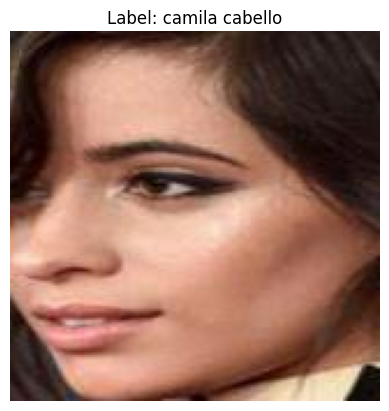

In [18]:
ds_iter = iter(train_loader)
ds_images, ds_labels = next(ds_iter)

image = ds_images[0].clone().detach().cpu().numpy()
image = image.transpose((1, 2, 0))
image = image * np.array(std) + np.array(mean)
image = np.clip(image, 0, 1)


plt.axis("off")
plt.title(f"Label: {labels[ds_labels[0].item()]}")
plt.imshow(image)

In [19]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device,
):
    history = []
    excel = os.path.join(CHECKPOINTS_FOLDER, f"{MODEL_NAME}_logs.xlsx")

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
            loop.set_postfix(loss=loss.item())

        model.eval()
        val_loss, val_correct = 0.0, 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        metrics = {
            "epoch": epoch + 1,
            "train_loss": train_loss / len(train_loader),
            "train_acc": train_correct.double().item() / len(train_loader.dataset),
            "val_loss": val_loss / len(val_loader),
            "val_acc": val_correct.double().item() / len(val_loader.dataset),
            "val_f1": f1_score(all_labels, all_preds, average="weighted"),
            "val_precision": precision_score(
                all_labels, all_preds, average="weighted", zero_division=0
            ),
            "val_recall": recall_score(all_labels, all_preds, average="weighted"),
        }

        history.append(metrics)

        print(
            f"Epoch {epoch+1}: Val Acc: {metrics['val_acc']:.4f} | F1: {metrics['val_f1']:.4f}"
        )

        df = pd.DataFrame(history)
        df.to_excel(excel, index=False)

        torch.save(
            model.state_dict(),
            os.path.join(CHECKPOINTS_FOLDER, f"{MODEL_NAME}_{epoch}.pth"),
        )
    return history

In [20]:
model = MyRecognitionModel(num_classes=len(labels))
summary(model=model)
model.to(device)    

MyRecognitionModel(
  (backbone): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): ConvBlock(
      (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (4): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), s

In [21]:
ds = dict()
for filename in train:
    class_name = (filename.split("_")[0]).lower()
    if class_name not in ds:
        ds[class_name] = []
    ds[class_name].append(filename)

In [22]:
for key, value in ds.items():
    print(f'{key}: {len(value)}')

akshay kumar: 40
alexandra daddario: 73
alia bhatt: 63
amitabh bachchan: 59
andy samberg: 73
anushka sharma: 54
billie eilish: 78
brad pitt: 96
camila cabello: 69
charlize theron: 62
claire holt: 76
courtney cox: 64
dwayne johnson: 48
elizabeth olsen: 56
ellen degeneres: 60
henry cavill: 84
hrithik roshan: 80
hugh jackman: 89
jessica alba: 86
kashyap: 24
lisa kudrow: 56
margot robbie: 57
marmik: 25
natalie portman: 84
priyanka chopra: 81
robert downey jr: 90
roger federer: 61
tom cruise: 46
vijay deverakonda: 92
virat kohli: 39
zac efron: 72


In [23]:
# train_indices = []
# for i in range(len(train_ds)):
#     _, label_idx = train_ds[i]
#     train_indices.append(int(label_idx))

# counts = Counter(train_indices)
# class_counts = [counts[i] for i in range(len(labels))]


# total_samples = sum(class_counts)
# num_classes = len(class_counts)

# weights = torch.tensor(
#     [total_samples / (num_classes * c) if c > 0 else 0.0 for c in class_counts],
#     dtype=torch.float,
# ).to(device)
# criterion = torch.nn.CrossEntropyLoss(weight=weights)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [24]:
# weights 

In [25]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

In [26]:
fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
)

Epoch 1: Val Acc: 0.0352 | F1: 0.0024


Epoch 2: Val Acc: 0.0352 | F1: 0.0024


Epoch 3: Val Acc: 0.0488 | F1: 0.0045


Epoch 4: Val Acc: 0.0488 | F1: 0.0045


Epoch 5: Val Acc: 0.0488 | F1: 0.0045


...

Epoch 125: Val Acc: 0.2358 | F1: 0.2200


Epoch 126: Val Acc: 0.2304 | F1: 0.2133


Epoch 127: Val Acc: 0.2141 | F1: 0.1994


Epoch 128: Val Acc: 0.2168 | F1: 0.1994


PermissionError: [Errno 13] Permission denied: '/mnt/d/projects/FaID-System/checkpoints/recognition_2/custom_logs.xlsx'